<a href="https://colab.research.google.com/github/zeugirdoR/ricci-flow-tokenization/blob/main/beta_sweep_ricci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BETA SWEEP EXPERIMENT

Corpus: 115623 train, 28906 test


Testing β = 0.00
Tokenization: 5407s
Compression: 80.35%
Train tokens: 23,718
Test tokens: 7,187
Training language model...
LM Training: 104s
Perplexity: 1.26

Testing β = 0.05
Tokenization: 5387s
Compression: 80.37%
Train tokens: 23,686
Test tokens: 7,234
Training language model...
LM Training: 98s
Perplexity: 1.40

Testing β = 0.10
Tokenization: 5388s
Compression: 80.37%
Train tokens: 23,686
Test tokens: 7,234
Training language model...
LM Training: 98s
Perplexity: 1.40

Testing β = 0.15
Tokenization: 5384s
Compression: 80.47%
Train tokens: 23,575
Test tokens: 7,238
Training language model...
LM Training: 98s
Perplexity: 1.42

Testing β = 0.20
Tokenization: 5380s
Compression: 80.48%
Train tokens: 23,555
Test tokens: 7,254
Training language model...
LM Training: 97s
Perplexity: 1.41

Testing β = 0.25
Tokenization: 5380s
Compression: 80.47%
Train tokens: 23,568
Test tokens: 7,252
Training language model...
LM Training: 97s
Perpl

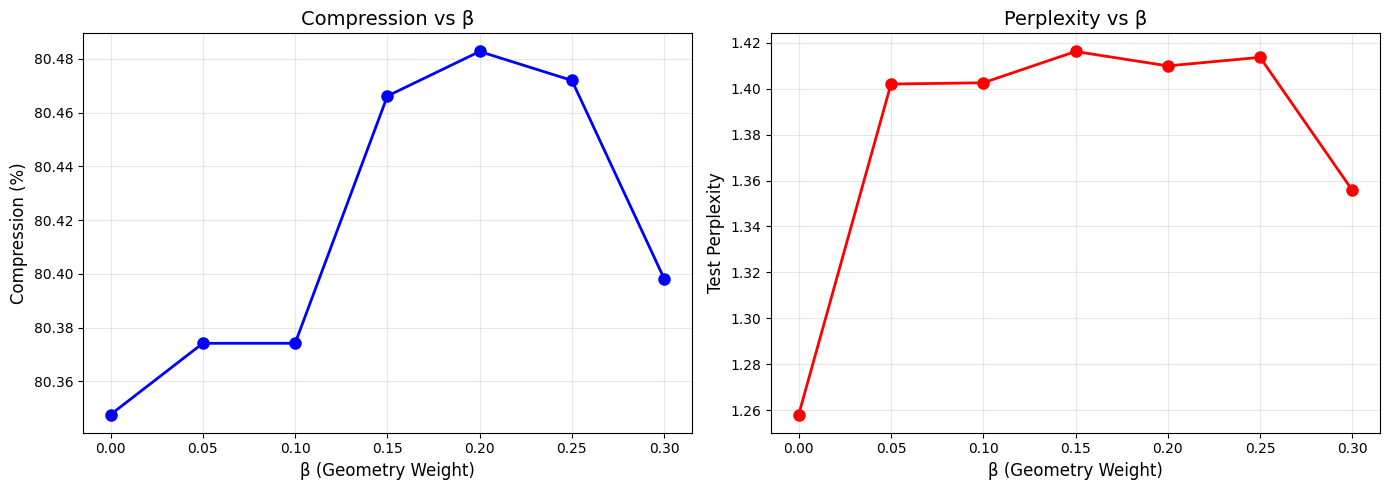

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pickle
import time
from collections import Counter
import matplotlib.pyplot as plt

class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=4, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(1024, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(x.size(0), -1)
        x = self.embedding(x) + self.pos_encoding(positions)
        x = self.transformer(x)
        return self.output(x)

class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len=128):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        self.seq_len = seq_len
    def __len__(self):
        return max(0, len(self.tokens) - self.seq_len - 1)
    def __getitem__(self, idx):
        return self.tokens[idx:idx+self.seq_len], self.tokens[idx+1:idx+self.seq_len+1]

def simple_wasserstein(p, q):
    return np.sum(np.abs(p - q))

def minimal_ricci_curvature(i, j, transition, alpha):
    n = transition.shape[0]
    mu_i = np.zeros(n)
    mu_i[i] = 1 - alpha
    mu_i += alpha * transition[i, :]
    mu_j = np.zeros(n)
    mu_j[j] = 1 - alpha
    mu_j += alpha * transition[j, :]
    return 1.0 - simple_wasserstein(mu_i, mu_j)

def hybrid_ricci_tokenizer(text, num_merges, alpha, beta):
    tokens = list(text.encode('utf-8'))
    vocab_size = 256
    merges = []

    for merge_num in range(num_merges):
        adjacency = np.zeros((vocab_size, vocab_size))
        for i in range(len(tokens) - 1):
            adjacency[tokens[i], tokens[i+1]] += 1

        row_sums = adjacency.sum(axis=1, keepdims=True)
        transition = adjacency / (row_sums + 1e-10)

        edges = [(i, j, adjacency[i, j]) for i in range(vocab_size)
                 for j in range(vocab_size) if adjacency[i, j] >= 2]

        if not edges:
            break

        max_freq = max(e[2] for e in edges)
        scores = []
        for i, j, freq in edges:
            kappa = minimal_ricci_curvature(i, j, transition, alpha)
            kappa_norm = (kappa + 1) / 2
            freq_norm = freq / max_freq
            hybrid = beta * kappa_norm + (1 - beta) * freq_norm
            scores.append((i, j, hybrid, kappa, freq))

        scores.sort(key=lambda x: x[2], reverse=True)
        best_i, best_j, _, _, _ = scores[0]
        merges.append((best_i, best_j))

        new_token = vocab_size
        vocab_size += 1
        i, new_tokens = 0, []
        while i < len(tokens):
            if i < len(tokens)-1 and tokens[i] == best_i and tokens[i+1] == best_j:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens

    return merges

def tokenize_with_vocab(text, merges):
    tokens = list(text.encode('utf-8'))
    for idx, (byte1, byte2) in enumerate(merges):
        new_token = 256 + idx
        i, new_tokens = 0, []
        while i < len(tokens):
            if i < len(tokens)-1 and tokens[i] == byte1 and tokens[i+1] == byte2:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens
    return tokens

def train_lm_fast(tokens_train, tokens_test, vocab_size, epochs=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TransformerLM(vocab_size).to(device)

    train_dataset = TokenDataset(tokens_train)
    test_dataset = TokenDataset(tokens_test)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
                test_loss += loss.item()

        test_ppl = np.exp(test_loss / len(test_loader))

    return test_ppl

print("="*80)
print("BETA SWEEP EXPERIMENT")
print("="*80)
print()

import urllib.request
url = "https://www.gutenberg.org/files/11/11-0.txt"
with urllib.request.urlopen(url) as response:
    alice_full = response.read().decode('utf-8')

start_idx = alice_full.find("CHAPTER I")
alice = alice_full[start_idx:start_idx+150000]
split = int(len(alice) * 0.8)
train_text, test_text = alice[:split], alice[split:]

print(f"Corpus: {len(train_text)} train, {len(test_text)} test")
print()

betas = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
results = []

for beta in betas:
    print(f"\n{'='*60}")
    print(f"Testing β = {beta:.2f}")
    print('='*60)

    start = time.time()
    merges = hybrid_ricci_tokenizer(train_text, 4000, alpha=0.8, beta=beta)
    train_tokens = tokenize_with_vocab(train_text, merges)
    test_tokens = tokenize_with_vocab(test_text, merges)
    tokenize_time = time.time() - start

    compression = (1 - len(train_tokens) / len(train_text.encode('utf-8'))) * 100
    print(f"Tokenization: {tokenize_time:.0f}s")
    print(f"Compression: {compression:.2f}%")
    print(f"Train tokens: {len(train_tokens):,}")
    print(f"Test tokens: {len(test_tokens):,}")

    print("Training language model...")
    start = time.time()
    ppl = train_lm_fast(train_tokens, test_tokens, 4256, epochs=10)
    lm_time = time.time() - start

    print(f"LM Training: {lm_time:.0f}s")
    print(f"Perplexity: {ppl:.2f}")

    results.append({
        'beta': beta,
        'compression': compression,
        'perplexity': ppl,
        'train_tokens': len(train_tokens),
        'test_tokens': len(test_tokens)
    })

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print()
print(f"{'Beta':<8} {'Compression':<14} {'Perplexity':<12} {'Tokens':<10}")
print("-"*50)

best_ppl = min(r['perplexity'] for r in results)
best_comp = max(r['compression'] for r in results)

for r in results:
    ppl_marker = " 🎉" if r['perplexity'] == best_ppl else ""
    comp_marker = " 📦" if r['compression'] == best_comp else ""
    print(f"{r['beta']:<8.2f} {r['compression']:<13.2f}%{comp_marker} "
          f"{r['perplexity']:<11.2f}{ppl_marker} {r['train_tokens']:<10,}")

print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot([r['beta'] for r in results], [r['compression'] for r in results],
         'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('β (Geometry Weight)', fontsize=12)
ax1.set_ylabel('Compression (%)', fontsize=12)
ax1.set_title('Compression vs β', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot([r['beta'] for r in results], [r['perplexity'] for r in results],
         'r-o', linewidth=2, markersize=8)
ax2.set_xlabel('β (Geometry Weight)', fontsize=12)
ax2.set_ylabel('Test Perplexity', fontsize=12)
ax2.set_title('Perplexity vs β', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('beta_sweep_results.pdf', dpi=300, bbox_inches='tight')
print("✓ Figure saved to beta_sweep_results.pdf")

pickle.dump(results, open('beta_sweep_results.pkl', 'wb'))
print("✓ Results saved to beta_sweep_results.pkl")

best_beta_ppl = min(results, key=lambda x: x['perplexity'])
best_beta_comp = max(results, key=lambda x: x['compression'])

print()
print("="*80)
print("CONCLUSION")
print("="*80)
print()
print(f"Best perplexity: β={best_beta_ppl['beta']:.2f}, PPL={best_beta_ppl['perplexity']:.2f}")
print(f"Best compression: β={best_beta_comp['beta']:.2f}, COMP={best_beta_comp['compression']:.2f}%")
print()

if best_beta_ppl['beta'] < 0.15:
    print("✓ Low β (mostly frequency) works best for LM!")
    print("  → Try even lower: β=0.01, 0.02, 0.03")
elif best_beta_ppl['perplexity'] < 1.23:
    print("🎉 Found β that beats BPE!")
    print(f"  → β={best_beta_ppl['beta']:.2f} achieves both good compression AND perplexity")
else:
    print("→ Need different approach - β alone may not be enough")
    print("  Next: Try varying α, larger dataset, or longer training")
